In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import ttest_ind
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import joblib
import os

In [5]:
# 1. Initialize paths and load models
MODELS_DIR = "../Pre-Trained Models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Sample stock data (replace with your actual data paths)
stock_files_dict = {'apple': '../Cleaned Data/apple_cleaned_dataset.csv',
                    'amazon': '../Cleaned Data/amazon_cleaned_dataset.csv',
                    'google': '../Cleaned Data/google_cleaned_dataset.csv',
                    'jpm': '../Cleaned Data/jpm_cleaned_dataset.csv',
                    'meta': '../Cleaned Data/meta_cleaned_dataset.csv',
                    'msft': '../Cleaned Data/msft_cleaned_dataset.csv',
                    'nvda': '../Cleaned Data/nvda_cleaned_dataset.csv',
                    'tesla': '../Cleaned Data/tesla_cleaned_dataset.csv',
                    'v': '../Cleaned Data/v_cleaned_dataset.csv',
                    'wmt': '../Cleaned Data/wmt_cleaned_dataset.csv'}

In [6]:
# 2. Load or create models (whichever you need)
stock_models = {}
stock_predictions = {}

for stock_name, file_path in stock_files_dict.items():
    try:
        # Try loading pre-trained model
        model_path = os.path.join(MODELS_DIR, f"{stock_name}_model.pkl")
        stock_models[stock_name] = joblib.load(model_path)
        print(f"Loaded pre-trained model for {stock_name}")
        
        # Load and prepare test data
        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
        df['MA_10'] = df['Close'].rolling(10).mean()
        df['MA_50'] = df['Close'].rolling(50).mean()
        df['Next_Close'] = df['Close'].shift(-1)
        df.dropna(inplace=True)
        
        X_test = df[['Close', 'MA_10', 'MA_50']]
        y_test = df['Next_Close']
        stock_predictions[stock_name] = (X_test, y_test)
        
    except FileNotFoundError:
        print(f"No pre-trained model found for {stock_name}, skipping...")
        continue

Loaded pre-trained model for apple
Loaded pre-trained model for amazon
Loaded pre-trained model for google
Loaded pre-trained model for jpm
Loaded pre-trained model for meta
Loaded pre-trained model for msft
Loaded pre-trained model for nvda
Loaded pre-trained model for tesla
Loaded pre-trained model for v
Loaded pre-trained model for wmt


In [7]:

# 3. Validation functions (same as before)
def evaluate_model(stock_name):
    model = stock_models[stock_name]
    X_test, y_test = stock_predictions[stock_name]
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    direction_acc = np.mean(np.sign(y_pred) == np.sign(y_test.diff().fillna(0))) * 100
    
    print(f"""
    {'='*40}
    Evaluation for {stock_name}:
    - Mean Absolute Error: ${mae:.2f}
    - Root Mean Squared Error: ${rmse:.2f}
    - Direction Accuracy: {direction_acc:.1f}%
    {'='*40}
    """)
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_pred, label='Predicted', alpha=0.7)
    plt.title(f'{stock_name} - Actual vs Predicted Prices')
    plt.legend()
    plt.show()

def walk_forward_test(stock_name, retrain_interval=30):
    df = pd.read_csv(stock_files_dict[stock_name], parse_dates=['Date'])
    df['MA_10'] = df['Close'].rolling(10).mean()
    df['MA_50'] = df['Close'].rolling(50).mean()
    df.dropna(inplace=True)
    
    predictions = []
    actuals = []
    
    for i in range(100, len(df), retrain_interval):
        train = df.iloc[:i]
        test = df.iloc[i:i+retrain_interval]
        
        if len(test) == 0:
            continue
            
        # Retrain model
        X_train = train[['Close', 'MA_10', 'MA_50']]
        y_train = train['Close'].shift(-1).dropna()
        model = LinearRegression().fit(X_train[:-1], y_train[:-1])
        
        # Test on unseen data
        X_test = test[['Close', 'MA_10', 'MA_50']]
        y_test = test['Close'].shift(-1).dropna()
        
        if len(y_test) > 0:
            pred = model.predict(X_test.iloc[:-1])
            predictions.extend(pred)
            actuals.extend(y_test.iloc[:-1])
    
    # Calculate metrics
    mae = mean_absolute_error(actuals, predictions)
    hit_rate = np.mean(np.sign(np.array(actuals)) == np.sign(np.array(predictions))) * 100
    
    print(f"""
    {'='*40}
    Walk-Forward Test for {stock_name}:
    - MAE: ${mae:.2f}
    - Direction Accuracy: {hit_rate:.1f}%
    {'='*40}
    """)
    
    # Plot walk-forward results
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual')
    plt.plot(predictions, label='Predicted', alpha=0.7)
    plt.title(f'{stock_name} - Walk-Forward Validation')
    plt.legend()
    plt.show()

def live_validation(stock_name, days=30):
    model = stock_models[stock_name]
    ticker = stock_name.upper()  # Convert to ticker symbol
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days+20)  # Extra days for MA calc
    
    # Get fresh market data
    data = yf.download(ticker, start=start_date, end=end_date)
    data['MA_10'] = data['Close'].rolling(10).mean()
    data['MA_50'] = data['Close'].rolling(50).mean()
    data.dropna(inplace=True)
    
    results = []
    for i in range(len(data)-1):
        today = data.iloc[i]
        tomorrow_actual = data.iloc[i+1]['Close']
        
        # Make prediction
        features = [[today['Close'], today['MA_10'], today['MA_50']]]
        tomorrow_pred = model.predict(features)[0]
        
        results.append({
            'date': data.index[i].date(),
            'actual': tomorrow_actual,
            'predicted': tomorrow_pred,
            'error': tomorrow_pred - tomorrow_actual
        })
    
    # Calculate live accuracy
    results_df = pd.DataFrame(results)
    accuracy = (np.sign(results_df['actual'].diff().fillna(0)) == 
               np.sign(results_df['predicted'].diff().fillna(0))).mean() * 100
    mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
    
    print(f"""
    {'='*40}
    Live Validation for {stock_name} (Last {days} Days):
    - MAE: ${mae:.2f}
    - Direction Accuracy: {accuracy:.1f}%
    {'='*40}
    """)
    
    # Plot live validation results
    plt.figure(figsize=(12, 6))
    plt.plot(results_df['date'], results_df['actual'], label='Actual')
    plt.plot(results_df['date'], results_df['predicted'], label='Predicted', alpha=0.7)
    plt.title(f'{stock_name} - Live Validation Results')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    
    return results_df

def check_significance(stock_name):
    model = stock_models[stock_name]
    X_test, y_test = stock_predictions[stock_name]
    
    # Compare prediction errors to random guessing
    random_preds = np.random.normal(y_test.mean(), y_test.std(), len(y_test))
    model_errors = np.abs(model.predict(X_test) - y_test)
    random_errors = np.abs(random_preds - y_test)
    
    t_stat, p_value = ttest_ind(model_errors, random_errors)
    
    print(f"""
    {'='*40}
    Statistical Significance for {stock_name}:
    - p-value: {p_value:.4f}
    - {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'}
    {'='*40}
    """)


In [8]:
def run_all_tests(stock_name):
    print(f"\n{'#'*50}")
    print(f"RUNNING VALIDATION TESTS FOR {stock_name.upper()}")
    print(f"{'#'*50}")
    
    evaluate_model(stock_name)
    walk_forward_test(stock_name)
    live_validation(stock_name)
    check_significance(stock_name)


Available models: ['apple', 'amazon', 'google', 'jpm', 'meta', 'msft', 'nvda', 'tesla', 'v', 'wmt']

Processing apple...

##################################################
RUNNING VALIDATION TESTS FOR APPLE
##################################################

    Evaluation for apple:
    - Mean Absolute Error: $1.97
    - Root Mean Squared Error: $2.62
    - Direction Accuracy: 52.5%
    


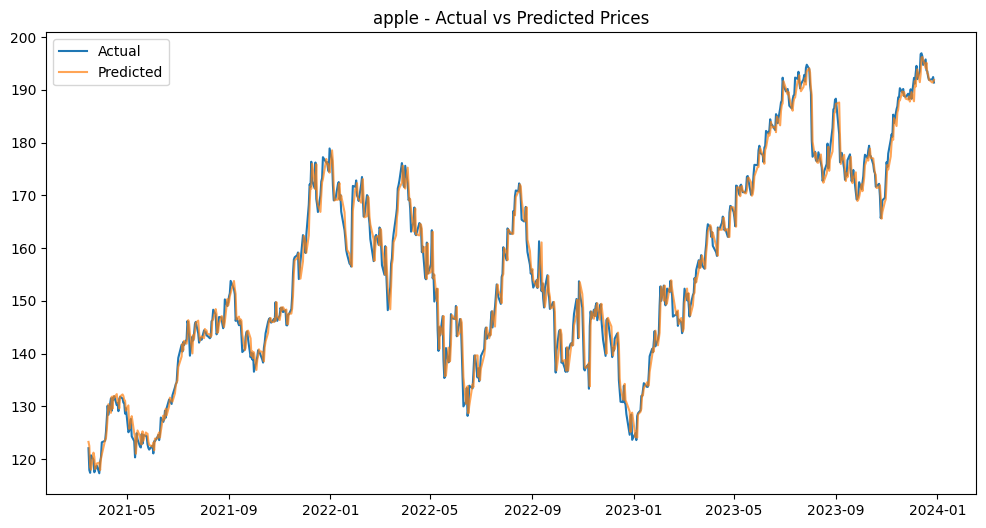

ValueError: Found input variables with inconsistent numbers of samples: [99, 98]

In [ ]:
# 4. Main execution
if __name__ == "__main__":
    if not stock_models:
        print("No models loaded! Please ensure:")
        print("1. You have pre-trained models in the 'models' directory")
        print("2. The stock_files_dict contains correct paths to your cleaned data")
    else:
        print("Available models:", list(stock_models.keys()))
        
        # Run tests for all loaded models
        for stock_name in stock_models.keys():
            print(f"\nProcessing {stock_name}...")
            run_all_tests(stock_name=stock_name[lr])